# Airbnb Agentic RAG — Ingestion Pipeline Walkthrough

This notebook walks through **every step of the ingestion pipeline** interactively:

| Step | What happens |
|------|--------------|
| 1 | Read `listings.csv.gz` from GCS — understand the raw dataset |
| 2 | Inspect a single row — all 79 columns |
| 3 | Build the **embedding text** — what gets sent to the model |
| 4 | Build the **metadata dict** — what gets stored in VS2.0 |
| 5 | Generate the **deterministic DataObject ID** (SHA1) |
| 6 | Call `text-embedding-005` — understand the 768-dim vector |
| 7 | Build a **VS2.0 DataObject** — the final structure |
| 8 | Upload a **single DataObject** to the collection |
| 9 | Verify the upload with a semantic search |
| 10 | Understand **batch processing** with retry logic |

> **Goal:** By the end you'll understand exactly what `scripts/02_ingest.py` does, row by row.

## 0 — Setup & Imports

In [28]:
import csv
import gzip
import hashlib
import io
import json
import sys
import time
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Add project root to path so we can import config.py
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import config

print(f"Project root : {PROJECT_ROOT}")
print(f"GCS URI      : {config.GCS_DATA_URI}")
print(f"Collection   : {config.COLLECTION_RESOURCE}")
print(f"Embedding    : {config.EMBEDDING_MODEL}")

Project root : /Users/kamaldhungana/Documents/Coding/GeminiCours101/GCP-RAG-Design/RAG-VertexAI/AirbnbAgenticRAG
GCS URI      : gs://rag-airbnb-listing/data/listings.csv.gz
Collection   : projects/deve-487713/locations/us-central1/collections/airbnb-listings-collection
Embedding    : text-embedding-005


In [29]:
# Initialize Vertex AI
import vertexai
vertexai.init(project=config.PROJECT_ID, location=config.LOCATION)
print(f"✓ Vertex AI initialised — project={config.PROJECT_ID}, location={config.LOCATION}")

✓ Vertex AI initialised — project=deve-487713, location=us-central1


---
## Step 1 — Read `listings.csv.gz` from GCS

The raw data lives in Google Cloud Storage. We download it as bytes and wrap it in `gzip.open` + `csv.DictReader` — no temp file needed.

In [30]:
from google.cloud import storage

gcs_path = f"{config.INPUT_PREFIX}{config.GCS_FILENAME}"   # "data/listings.csv.gz"

print(f"Downloading gs://{config.BUCKET_NAME}/{gcs_path} ...")
storage_client = storage.Client(project=config.PROJECT_ID)
bucket = storage_client.bucket(config.BUCKET_NAME)
blob   = bucket.blob(gcs_path)

raw_bytes = blob.download_as_bytes()
print(f"✓ Downloaded {len(raw_bytes) / 1_048_576:.2f} MB")

✓ Downloaded 6.23 MB


In [31]:
# Parse the gzipped CSV — reads ALL rows into a list of dicts
all_rows = []
with gzip.open(io.BytesIO(raw_bytes), "rt", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    column_names = reader.fieldnames   # save column list
    for row in reader:
        all_rows.append(row)

print(f"Total rows    : {len(all_rows):,}")
print(f"Total columns : {len(column_names)}")
print(f"\nAll {len(column_names)} column names:")
for i, col in enumerate(column_names):
    print(f"  {i+1:2d}. {col}")

Total rows    : 10,533
Total columns : 79

All 79 column names:
   1. id
   2. listing_url
   3. scrape_id
   4. last_scraped
   5. source
   6. name
   7. description
   8. neighborhood_overview
   9. picture_url
  10. host_id
  11. host_url
  12. host_name
  13. host_since
  14. host_location
  15. host_about
  16. host_response_time
  17. host_response_rate
  18. host_acceptance_rate
  19. host_is_superhost
  20. host_thumbnail_url
  21. host_picture_url
  22. host_neighbourhood
  23. host_listings_count
  24. host_total_listings_count
  25. host_verifications
  26. host_has_profile_pic
  27. host_identity_verified
  28. neighbourhood
  29. neighbourhood_cleansed
  30. neighbourhood_group_cleansed
  31. latitude
  32. longitude
  33. property_type
  34. room_type
  35. accommodates
  36. bathrooms
  37. bathrooms_text
  38. bedrooms
  39. beds
  40. amenities
  41. price
  42. minimum_nights
  43. maximum_nights
  44. minimum_minimum_nights
  45. maximum_minimum_nights
  46. minimum

In [32]:
# Quick dataset overview with pandas
df_preview = pd.DataFrame(all_rows[:5])
print("Shape of preview DataFrame:", df_preview.shape)
df_preview[["id", "name", "neighbourhood_cleansed", "room_type", "price", "bedrooms", "accommodates"]].head()

Shape of preview DataFrame: (5, 79)


,id,name,neighbourhood_cleansed,room_type,price,bedrooms,accommodates
0,5456,"Walk to 6th, Rainey St and Convention Ctr",78702,Entire home/apt,$97.00,1,3
1,6448,"Secluded Studio @ Zilker - King Bed, Bright & ...",78704,Entire home/apt,$160.00,1,2
2,8502,Woodland Studio Lodging,78741,Entire home/apt,$38.00,1,2
3,13035,Historic house in highly walkable East Austin,78702,Entire home/apt,$145.00,2,3
4,22828,Garage Apartment central SE Austin,78741,Entire home/apt,$58.00,1,2


---
## Step 2 — Inspect a Single Row (all 79 fields)

Let's pick **Row 0** and look at every field. `csv.DictReader` returns every value as a `str` — notice that `price` is `'$97.00'`, booleans are `'t'`/`'f'`, and missing values are just empty strings `''`.

In [33]:
ROW_INDEX = 0          # ← change this to inspect any row
raw_row = all_rows[ROW_INDEX]

print(f"=== Raw Row {ROW_INDEX} (Listing ID: {raw_row['id']}) ===")
print(f"All {len(raw_row)} fields:")
print()

for key, val in raw_row.items():
    # Truncate long values for readability
    display_val = val[:120] + "..." if len(val) > 120 else val
    print(f"  {key:<35} = {repr(display_val)}")

=== Raw Row 0 (Listing ID: 5456) ===
All 79 fields:

  id                                  = '5456'
  listing_url                         = 'https://www.airbnb.com/rooms/5456'
  scrape_id                           = '20250916040734'
  last_scraped                        = '2025-09-17'
  source                              = 'city scrape'
  name                                = 'Walk to 6th, Rainey St and Convention Ctr'
  description                         = 'Great central  location for walking to Convention Center, Rainey Street, East 6th Street, Downtown, Congress Ave Bats.<b...'
  neighborhood_overview               = 'My neighborhood is ideally located if you want to walk to bars and restaurants downtown, East 6th Street or Rainey Stree...'
  picture_url                         = 'https://a0.muscache.com/pictures/14084884/b5a35a84_original.jpg'
  host_id                             = '8028'
  host_url                            = 'https://www.airbnb.com/users/show/8028'
  host_nam

In [34]:
# Highlight the key fields we actually USE
KEY_FIELDS = [
    "id", "listing_url", "name", "description", "neighborhood_overview",
    "neighbourhood_cleansed", "room_type", "property_type",
    "accommodates", "bedrooms", "beds", "bathrooms_text",
    "price", "review_scores_rating",
    "host_name", "host_is_superhost", "instant_bookable",
    "latitude", "longitude",
]

print(f"Key fields used in ingestion (from Row {ROW_INDEX}):")
print("-" * 60)
for k in KEY_FIELDS:
    val = raw_row.get(k, "<missing>")
    display_val = val[:100] + "..." if len(val) > 100 else val
    print(f"  {k:<30} = {repr(display_val)}")

Key fields used in ingestion (from Row 0):
------------------------------------------------------------
  id                             = '5456'
  listing_url                    = 'https://www.airbnb.com/rooms/5456'
  name                           = 'Walk to 6th, Rainey St and Convention Ctr'
  description                    = 'Great central  location for walking to Convention Center, Rainey Street, East 6th Street, Downtown, ...'
  neighborhood_overview          = 'My neighborhood is ideally located if you want to walk to bars and restaurants downtown, East 6th St...'
  neighbourhood_cleansed         = '78702'
  room_type                      = 'Entire home/apt'
  property_type                  = 'Entire guesthouse'
  accommodates                   = '3'
  bedrooms                       = '1'
  beds                           = '2'
  bathrooms_text                 = '1 bath'
  price                          = '$97.00'
  review_scores_rating           = '4.85'
  host_name             

---
## Step 3 — Build the Embedding Text

The embedding model receives a **single string** per listing. We concatenate the most semantically rich fields. The goal is to capture *what this place is* in natural language so the vector search finds it when users describe what they want.

```
embedding_text = name  +  description[:600]  +  neighbourhood
              +  room_type + accommodates  +  neighborhood_overview[:400]
              +  bedrooms/beds/bathrooms
```

In [35]:
def build_embedding_text(row: dict) -> str:
    """Build rich text for embedding — exact copy from 02_ingest.py."""
    parts = []

    if row.get("name"):
        parts.append(row["name"].strip())

    if row.get("description"):
        desc = row["description"].strip()
        if desc:
            parts.append(desc[:600])

    neighbourhood = row.get("neighbourhood_cleansed") or row.get("neighbourhood", "")
    if neighbourhood.strip():
        parts.append(f"Located in {neighbourhood.strip()}.")

    room_type   = row.get("room_type", "")
    accommodates = row.get("accommodates", "")
    if room_type or accommodates:
        detail = f"{room_type}" if room_type else ""
        if accommodates:
            detail += f". Accommodates {accommodates} guests"
        parts.append(detail.strip(". ") + ".")

    if row.get("neighborhood_overview"):
        overview = row["neighborhood_overview"].strip()
        if overview:
            parts.append(overview[:400])

    bedrooms  = row.get("bedrooms", "")
    beds      = row.get("beds", "")
    bathrooms = row.get("bathrooms_text", "")
    if bedrooms or beds or bathrooms:
        props = []
        if bedrooms:  props.append(f"{bedrooms} bedroom(s)")
        if beds:      props.append(f"{beds} bed(s)")
        if bathrooms: props.append(bathrooms)
        parts.append(", ".join(props) + ".")

    return " ".join(parts)

In [36]:
# Build embedding text for our sample row — step by step
row = all_rows[ROW_INDEX]

print("=== Embedding Text Components ===")
print()
print(f"[1] name               : {repr(row.get('name', '')[:80])}")
print(f"[2] description[:600]  : {repr(row.get('description', '')[:80])}...")
print(f"[3] neighbourhood      : {repr(row.get('neighbourhood_cleansed', ''))}")
print(f"[4] room_type          : {repr(row.get('room_type', ''))}")
print(f"[5] accommodates       : {repr(row.get('accommodates', ''))}")
print(f"[6] neighborhood_overview[:400]: {repr(row.get('neighborhood_overview', '')[:80])}...")
print(f"[7] bedrooms/beds/bath : {row.get('bedrooms','')} bed(s) / {row.get('beds','')} beds / {row.get('bathrooms_text','')}")
print()

embedding_text = build_embedding_text(row)

print("=== Final Embedding Text ===")
print(f"Character length: {len(embedding_text)}")
print()
print(embedding_text)

=== Embedding Text Components ===

[1] name               : 'Walk to 6th, Rainey St and Convention Ctr'
[2] description[:600]  : 'Great central  location for walking to Convention Center, Rainey Street, East 6t'...
[3] neighbourhood      : '78702'
[4] room_type          : 'Entire home/apt'
[5] accommodates       : '3'
[6] neighborhood_overview[:400]: 'My neighborhood is ideally located if you want to walk to bars and restaurants d'...
[7] bedrooms/beds/bath : 1 bed(s) / 2 beds / 1 bath

=== Final Embedding Text ===
Character length: 557

Walk to 6th, Rainey St and Convention Ctr Great central  location for walking to Convention Center, Rainey Street, East 6th Street, Downtown, Congress Ave Bats.<br /><br />  Free wifi<br /><br />No Smoking,  No pets Located in 78702. Entire home/apt. Accommodates 3 guests. My neighborhood is ideally located if you want to walk to bars and restaurants downtown, East 6th Street or Rainey Street.  The Convention Center is only 3 1/2 blocks away and a quic

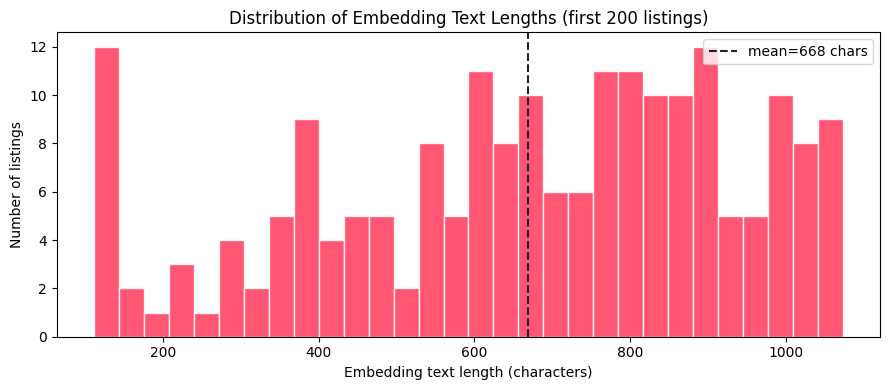

Min: 112  Max: 1073  Mean: 668


In [37]:
# Compare embedding text lengths across 200 listings
sample_lengths = [len(build_embedding_text(r)) for r in all_rows[:200]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample_lengths, bins=30, color="#FF385C", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(sample_lengths), color="#222", linestyle="--", label=f"mean={np.mean(sample_lengths):.0f} chars")
ax.set_xlabel("Embedding text length (characters)")
ax.set_ylabel("Number of listings")
ax.set_title("Distribution of Embedding Text Lengths (first 200 listings)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min: {min(sample_lengths)}  Max: {max(sample_lengths)}  Mean: {np.mean(sample_lengths):.0f}")

---
## Step 4 — Build the Metadata Dictionary

This is what gets **stored** in VS2.0 alongside the vector. Three field transformations happen here:

| Raw CSV value | Transformation | Result |
|---|---|---|
| `"$97.00"` | `parse_price()` | `97.0` |
| `"t"` / `"f"` | `parse_bool_str()` | `"true"` / `"false"` |
| `"4.85"` | `parse_float()` | `4.85` |
| `""` (empty) | `parse_float()` | `0.0` (default) |

In [38]:
# ── Helper functions (copied from 02_ingest.py) ──────────────────────────────

def parse_price(price_str: str) -> float | None:
    """'$97.00' → 97.0"""
    if not price_str:
        return None
    cleaned = price_str.replace("$", "").replace(",", "").strip()
    try:
        return float(cleaned)
    except ValueError:
        return None

def parse_float(value: str) -> float | None:
    if not value or value.strip() == "":
        return None
    try:
        return float(value)
    except ValueError:
        return None

def parse_bool_str(value: str) -> str:
    """'t' → 'true', 'f' → 'false'"""
    return "true" if value.strip().lower() in {"t", "true", "1", "yes"} else "false"


# ── Demonstrate each transformation ─────────────────────────────────────────
print("=== Transformation Examples ===")
print()
price_raw = row.get("price", "")
print(f"price:               raw={repr(price_raw):<12}  →  parsed={parse_price(price_raw)}")

superhost_raw = row.get("host_is_superhost", "")
print(f"host_is_superhost:   raw={repr(superhost_raw):<12}  →  parsed={repr(parse_bool_str(superhost_raw))}")

bookable_raw = row.get("instant_bookable", "")
print(f"instant_bookable:    raw={repr(bookable_raw):<12}  →  parsed={repr(parse_bool_str(bookable_raw))}")

rating_raw = row.get("review_scores_rating", "")
print(f"review_scores_rating:raw={repr(rating_raw):<12}  →  parsed={parse_float(rating_raw)}")

beds_raw = row.get("beds", "")
print(f"beds (possibly ''):  raw={repr(beds_raw):<12}  →  parsed={parse_float(beds_raw)}  (→ default 0.0 on None)")

=== Transformation Examples ===

price:               raw='$97.00'      →  parsed=97.0
host_is_superhost:   raw='t'           →  parsed='true'
instant_bookable:    raw='f'           →  parsed='false'
review_scores_rating:raw='4.85'        →  parsed=4.85
beds (possibly ''):  raw='2'           →  parsed=2.0  (→ default 0.0 on None)


In [39]:
# Build full metadata dict for this row
def build_metadata(row: dict) -> dict:
    """Build the metadata dict stored in VS2.0 — exact copy from 02_ingest.py."""
    text  = build_embedding_text(row)
    price = parse_price(row.get("price", ""))
    return {
        # ── Textual ──────────────────────────────────────────────────────────
        "name":              (row.get("name") or "")[:500],
        "neighbourhood":     row.get("neighbourhood_cleansed") or "",
        "property_type":     row.get("property_type") or "",
        "room_type":         row.get("room_type") or "",
        "bathrooms_text":    row.get("bathrooms_text") or "",
        "listing_url":       row.get("listing_url") or "",
        "host_name":         row.get("host_name") or "",
        "host_is_superhost": parse_bool_str(row.get("host_is_superhost", "")),
        "instant_bookable":  parse_bool_str(row.get("instant_bookable", "")),
        "text":              text[:2000],
        # ── Numeric ──────────────────────────────────────────────────────────
        "accommodates": parse_float(row.get("accommodates", "")) or 0.0,
        "bedrooms":     parse_float(row.get("bedrooms", "")) or 0.0,
        "beds":         parse_float(row.get("beds", "")) or 0.0,
        "price":        price if price is not None else 0.0,
        "rating":       parse_float(row.get("review_scores_rating", "")) or 0.0,
        "latitude":     parse_float(row.get("latitude", "")) or 0.0,
        "longitude":    parse_float(row.get("longitude", "")) or 0.0,
    }

metadata = build_metadata(row)

print(f"=== Metadata for Row {ROW_INDEX} (Listing ID: {row['id']}) ===")
print()
for k, v in metadata.items():
    if k == "text":
        print(f"  {k:<25} = {repr(str(v)[:80])}...  [{len(str(v))} chars]")
    else:
        print(f"  {k:<25} = {repr(v)}")

=== Metadata for Row 0 (Listing ID: 5456) ===

  name                      = 'Walk to 6th, Rainey St and Convention Ctr'
  neighbourhood             = '78702'
  property_type             = 'Entire guesthouse'
  room_type                 = 'Entire home/apt'
  bathrooms_text            = '1 bath'
  listing_url               = 'https://www.airbnb.com/rooms/5456'
  host_name                 = 'Sylvia'
  host_is_superhost         = 'true'
  instant_bookable          = 'false'
  text                      = 'Walk to 6th, Rainey St and Convention Ctr Great central  location for walking to'...  [557 chars]
  accommodates              = 3.0
  bedrooms                  = 1.0
  beds                      = 2.0
  price                     = 97.0
  rating                    = 4.85
  latitude                  = 30.26057
  longitude                 = -97.73441


In [40]:
# VS2.0 schema types: string fields vs number fields
string_fields = ["name","neighbourhood","property_type","room_type","bathrooms_text",
                 "listing_url","host_name","host_is_superhost","instant_bookable","text"]
number_fields = ["accommodates","bedrooms","beds","price","rating","latitude","longitude"]

print("Fields stored in VS2.0 data_schema:")
print()
print(f"  STRING fields ({len(string_fields)}):")
for f in string_fields:
    print(f"    • {f:<25} = {repr(metadata[f])[:60]}")
print()
print(f"  NUMBER fields ({len(number_fields)}):")
for f in number_fields:
    print(f"    • {f:<25} = {metadata[f]}")

Fields stored in VS2.0 data_schema:

  STRING fields (10):
    • name                      = 'Walk to 6th, Rainey St and Convention Ctr'
    • neighbourhood             = '78702'
    • property_type             = 'Entire guesthouse'
    • room_type                 = 'Entire home/apt'
    • bathrooms_text            = '1 bath'
    • listing_url               = 'https://www.airbnb.com/rooms/5456'
    • host_name                 = 'Sylvia'
    • host_is_superhost         = 'true'
    • instant_bookable          = 'false'
    • text                      = 'Walk to 6th, Rainey St and Convention Ctr Great central  lo

  NUMBER fields (7):
    • accommodates              = 3.0
    • bedrooms                  = 1.0
    • beds                      = 2.0
    • price                     = 97.0
    • rating                    = 4.85
    • latitude                  = 30.26057
    • longitude                 = -97.73441


---
## Step 5 — Generate the Deterministic DataObject ID

We use `SHA1("airbnb:{listing_id}")` to create a **deterministic, collision-free ID**. This ensures:
- Re-running ingestion produces the **same ID** → `AlreadyExists` is silently skipped
- No need for an external ID store
- Human-readable prefix ensures namespace isolation

In [41]:
def make_listing_id(listing_id: str) -> str:
    """Deterministic SHA1 from the Airbnb listing_id."""
    return hashlib.sha1(f"airbnb:{listing_id}".encode()).hexdigest()

listing_id = row["id"]
obj_id     = make_listing_id(listing_id)

print(f"Raw Airbnb listing_id : {listing_id}")
print(f"Input to SHA1         : 'airbnb:{listing_id}'")
print(f"SHA1 hex digest       : {obj_id}")
print(f"Length                : {len(obj_id)} characters (160-bit SHA1)")
print()
print("Idempotency check — same input always gives same ID:")
print(f"  Run 1: {make_listing_id(listing_id)}")
print(f"  Run 2: {make_listing_id(listing_id)}")
print(f"  Match: {make_listing_id(listing_id) == obj_id}")

Raw Airbnb listing_id : 5456
Input to SHA1         : 'airbnb:5456'
SHA1 hex digest       : 0833b5d04f16a6cc9ac0609e49d74ad2f3acf4cf
Length                : 40 characters (160-bit SHA1)

Idempotency check — same input always gives same ID:
  Run 1: 0833b5d04f16a6cc9ac0609e49d74ad2f3acf4cf
  Run 2: 0833b5d04f16a6cc9ac0609e49d74ad2f3acf4cf
  Match: True


In [42]:
# Show IDs for first 5 rows
print("DataObject IDs for first 5 rows:")
print(f"  {'Airbnb ID':<12}  {'SHA1 DataObject ID':<42}")
print("  " + "-" * 55)
for r in all_rows[:5]:
    print(f"  {r['id']:<12}  {make_listing_id(r['id'])}")

DataObject IDs for first 5 rows:
  Airbnb ID     SHA1 DataObject ID                        
  -------------------------------------------------------
  5456          0833b5d04f16a6cc9ac0609e49d74ad2f3acf4cf
  6448          a0deef778dff2094f304c6d996ff3388ac5ccaee
  8502          aa4b947e70f2fc95bde9bcf5694071d68f41e646
  13035         d24d5c482bc983907ad7e3adcdbdfd3c0de23923
  22828         90069d83e74fc024a2f546d9ca3ab5693a53e048


---
## Step 6 — Generate the Embedding Vector

We call `text-embedding-005` (Google's state-of-the-art text embedding model). It returns a **768-dimensional float vector** — a point in a high-dimensional semantic space where similar listings are close to each other.

**Key properties:**
- 768 floats per listing
- Optimised for retrieval with `DOT_PRODUCT` similarity
- Supports up to 2048 input tokens

In [43]:
from vertexai.language_models import TextEmbeddingModel

embedding_model = TextEmbeddingModel.from_pretrained(config.EMBEDDING_MODEL)
print(f"✓ Loaded embedding model: {config.EMBEDDING_MODEL}")

✓ Loaded embedding model: text-embedding-005


In [44]:
# Embed a single listing
embedding_text = build_embedding_text(row)

print("Calling text-embedding-005 for one listing...")
t0 = time.time()
[result] = embedding_model.get_embeddings([embedding_text])   # returns a list
elapsed = time.time() - t0

vector = result.values   # Python list of floats

print(f"✓ Done in {elapsed:.2f}s")
print()
print(f"Input text length : {len(embedding_text)} characters")
print(f"Vector dimensions : {len(vector)}")
print(f"Vector dtype      : {type(vector[0]).__name__}")
print(f"Value range       : [{min(vector):.4f}, {max(vector):.4f}]")
print(f"L2 norm           : {sum(v**2 for v in vector)**0.5:.6f}  (not unit — DOT_PRODUCT similarity)")
print()
print(f"First 10 values   : {[round(v, 5) for v in vector[:10]]}")

Calling text-embedding-005 for one listing...
✓ Done in 0.36s

Input text length : 557 characters
Vector dimensions : 768
Vector dtype      : float
Value range       : [-0.1297, 0.1218]
L2 norm           : 0.999987  (not unit — DOT_PRODUCT similarity)

First 10 values   : [-0.03897, -0.01557, -0.01575, 0.00717, -0.00921, -0.00973, 0.01231, -0.0028, -0.02503, -0.0027]


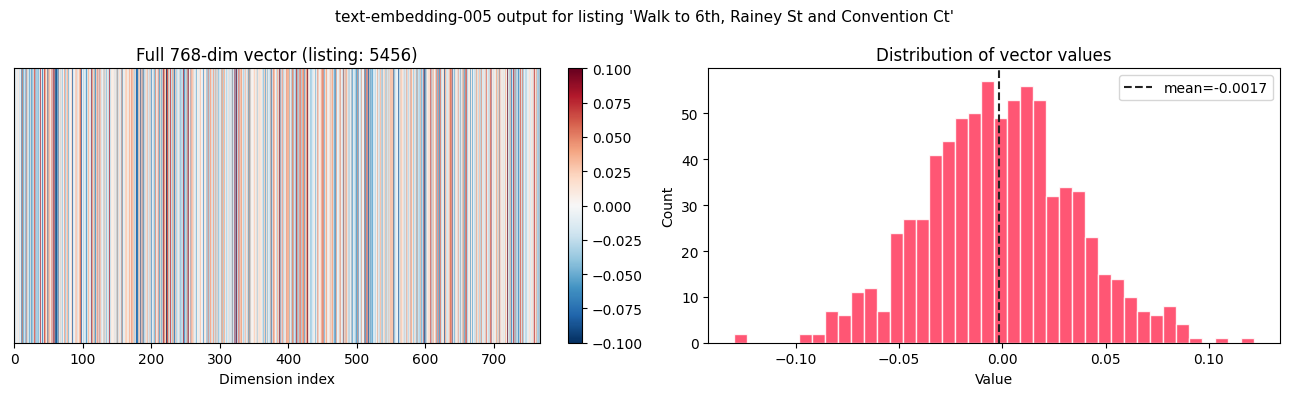

In [45]:
# Visualise the 768-dim vector
vec = np.array(vector)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full 768-dim vector as a heatmap strip
axes[0].imshow(vec.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=-0.1, vmax=0.1)
axes[0].set_title(f"Full 768-dim vector (listing: {row['id']})")
axes[0].set_xlabel("Dimension index")
axes[0].set_yticks([])
plt.colorbar(axes[0].images[0], ax=axes[0], fraction=0.03)

# Right: histogram of all 768 values
axes[1].hist(vec, bins=40, color="#FF385C", edgecolor="white", alpha=0.85)
axes[1].axvline(vec.mean(), color="#222", linestyle="--", label=f"mean={vec.mean():.4f}")
axes[1].set_title("Distribution of vector values")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle(f"text-embedding-005 output for listing '{row['name'][:40]}'", fontsize=11)
plt.tight_layout()
plt.show()

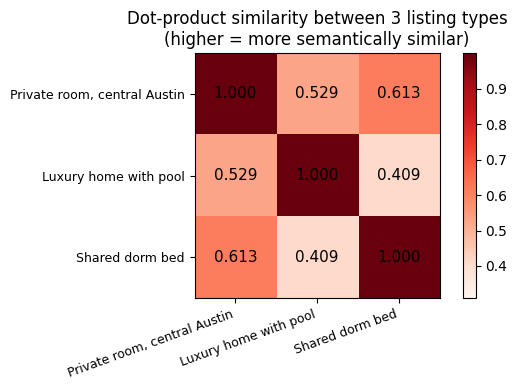

In [46]:
# Compare embeddings for 3 different listings — semantically similar listings
# should have higher dot-product similarity
sample_texts = [
    ("Cozy private room near downtown",      "Private room, central Austin"),
    ("Luxurious entire home with pool",       "Luxury home with pool"),
    ("Shared hostel bed in East Austin",      "Shared dorm bed"),
]

texts = [t[0] for t in sample_texts]
labels = [t[1] for t in sample_texts]
embeddings = embedding_model.get_embeddings(texts)
vecs = [np.array(e.values) for e in embeddings]

# Dot-product similarity matrix
sim = np.array([[np.dot(vecs[i], vecs[j]) for j in range(3)] for i in range(3)])

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(sim, cmap="Reds", vmin=sim.min()-0.1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{sim[i,j]:.3f}", ha="center", va="center", fontsize=11, color="black")
ax.set_title("Dot-product similarity between 3 listing types\n(higher = more semantically similar)")
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

---
## Step 7 — Build a VS2.0 DataObject

A `DataObject` is the unit of storage in Vertex AI Vector Search 2.0. It bundles together:
- `data_object_id` — the deterministic SHA1 ID
- `data` — the metadata dictionary (all string + number fields)
- `vectors` — a dict mapping field name → `Vector(DenseVector(values=[...]))`

In our schema, the vector field is always called `"embedding"`.

In [47]:
from google.cloud import vectorsearch_v1beta as vs

def build_data_object(obj_id: str, metadata: dict, embedding: list) -> vs.DataObject:
    """Build a VS2.0 DataObject — exact copy from 02_ingest.py."""
    return vs.DataObject(
        data_object_id=obj_id,
        data=metadata,
        vectors={
            "embedding": vs.Vector(
                dense=vs.DenseVector(values=embedding)
            )
        },
    )

data_obj = build_data_object(
    obj_id   = obj_id,
    metadata = metadata,
    embedding = list(vector),
)

print("=== VS2.0 DataObject Structure ===")
print(f"  data_object_id : {data_obj.data_object_id}")
print()
print("  data (metadata fields):")
for k, v in data_obj.data.items():
    display = repr(str(v)[:60]) if k == "text" else repr(v)
    print(f"    {k:<25} = {display}")
print()
print("  vectors:")
emb_values = data_obj.vectors["embedding"].dense.values
print(f"    'embedding' field: DenseVector with {len(emb_values)} floats")
print(f"    First 5 values   : {list(emb_values[:5])}")

=== VS2.0 DataObject Structure ===
  data_object_id : 0833b5d04f16a6cc9ac0609e49d74ad2f3acf4cf

  data (metadata fields):
    bathrooms_text            = '1 bath'
    beds                      = 2.0
    longitude                 = -97.73441
    price                     = 97.0
    rating                    = 4.85
    room_type                 = 'Entire home/apt'
    instant_bookable          = 'false'
    host_name                 = 'Sylvia'
    name                      = 'Walk to 6th, Rainey St and Convention Ctr'
    text                      = 'Walk to 6th, Rainey St and Convention Ctr Great central  loc'
    host_is_superhost         = 'true'
    bedrooms                  = 1.0
    neighbourhood             = '78702'
    latitude                  = 30.26057
    property_type             = 'Entire guesthouse'
    accommodates              = 3.0
    listing_url               = 'https://www.airbnb.com/rooms/5456'

  vectors:
    'embedding' field: DenseVector with 768 floats
    Firs

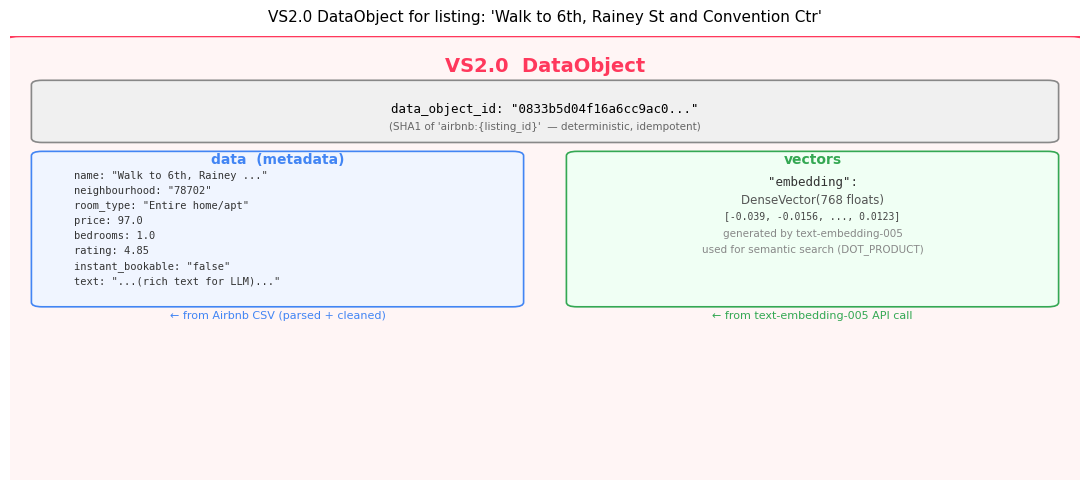

In [48]:
# Visual diagram of the DataObject structure
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis("off")

# DataObject outer box
outer = mpatches.FancyBboxPatch((0.01, 0.01), 0.98, 0.97,
    boxstyle="round,pad=0.02", linewidth=2, edgecolor="#FF385C", facecolor="#fff5f5")
ax.add_patch(outer)
ax.text(0.5, 0.93, "VS2.0  DataObject", ha="center", va="center",
        fontsize=14, fontweight="bold", color="#FF385C")

# ID box
id_box = mpatches.FancyBboxPatch((0.03, 0.77), 0.94, 0.12,
    boxstyle="round,pad=0.01", linewidth=1.2, edgecolor="#888", facecolor="#f0f0f0")
ax.add_patch(id_box)
ax.text(0.5, 0.835, f"data_object_id: \"{data_obj.data_object_id[:20]}...\"",
        ha="center", va="center", fontsize=9, family="monospace")
ax.text(0.5, 0.795, "(SHA1 of 'airbnb:{listing_id}'  — deterministic, idempotent)",
        ha="center", va="center", fontsize=7.5, color="#666")

# Data box
data_box = mpatches.FancyBboxPatch((0.03, 0.40), 0.44, 0.33,
    boxstyle="round,pad=0.01", linewidth=1.2, edgecolor="#4285F4", facecolor="#f0f5ff")
ax.add_patch(data_box)
ax.text(0.25, 0.72, "data  (metadata)", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#4285F4")
data_items = [
    f"name: \"{metadata['name'][:20]}...\"",
    f"neighbourhood: \"{metadata['neighbourhood']}\"",
    f"room_type: \"{metadata['room_type']}\"",
    f"price: {metadata['price']}",
    f"bedrooms: {metadata['bedrooms']}",
    f"rating: {metadata['rating']}",
    f"instant_bookable: \"{metadata['instant_bookable']}\"",
    "text: \"...(rich text for LLM)...\"",
]
for i, item in enumerate(data_items):
    ax.text(0.06, 0.685 - i * 0.034, item, va="center",
            fontsize=7.5, family="monospace", color="#333")

# Vectors box
vec_box = mpatches.FancyBboxPatch((0.53, 0.40), 0.44, 0.33,
    boxstyle="round,pad=0.01", linewidth=1.2, edgecolor="#34A853", facecolor="#f0fff4")
ax.add_patch(vec_box)
ax.text(0.75, 0.72, "vectors", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#34A853")
ax.text(0.75, 0.67, "\"embedding\":", ha="center", va="center",
        fontsize=9, family="monospace", color="#333")
ax.text(0.75, 0.63, "DenseVector(768 floats)", ha="center", va="center",
        fontsize=8.5, color="#555")
ax.text(0.75, 0.595, f"[{round(vector[0],4)}, {round(vector[1],4)}, ..., {round(vector[-1],4)}]",
        ha="center", va="center", fontsize=7, family="monospace", color="#444")
ax.text(0.75, 0.555, "generated by text-embedding-005", ha="center", va="center",
        fontsize=7.5, color="#888")
ax.text(0.75, 0.52, "used for semantic search (DOT_PRODUCT)", ha="center", va="center",
        fontsize=7.5, color="#888")

# Source labels
ax.text(0.25, 0.37, "← from Airbnb CSV (parsed + cleaned)", ha="center", va="center",
        fontsize=8, color="#4285F4")
ax.text(0.75, 0.37, "← from text-embedding-005 API call", ha="center", va="center",
        fontsize=8, color="#34A853")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"VS2.0 DataObject for listing: '{metadata['name'][:50]}'",
             fontsize=11, pad=10)
plt.tight_layout()
plt.show()

---
## Step 8 — Upload a Single DataObject to VS2.0

Now we actually call the VS2.0 API to upload our DataObject. VS2.0 stores both the vector and the metadata together — no Firestore needed.

In [49]:
from google.api_core.exceptions import AlreadyExists

do_client = vs.DataObjectServiceClient()
parent    = config.COLLECTION_RESOURCE   # "projects/.../collections/airbnb-listings-collection"

print(f"Uploading DataObject to:")
print(f"  parent : {parent}")
print(f"  obj_id : {data_obj.data_object_id}")
print()

try:
    create_req = vs.CreateDataObjectRequest(
        parent          = parent,
        data_object_id  = data_obj.data_object_id,
        data_object     = data_obj,
    )
    t0 = time.time()
    response = do_client.create_data_object(request=create_req)
    elapsed  = time.time() - t0
    print(f"✓ Created in {elapsed:.2f}s")
    print(f"  name: {response.name}")

except AlreadyExists:
    print("ℹ DataObject already exists (idempotent — this is fine)")
    print("  This listing was already ingested by 02_ingest.py")

Uploading DataObject to:
  parent : projects/deve-487713/locations/us-central1/collections/airbnb-listings-collection
  obj_id : 0833b5d04f16a6cc9ac0609e49d74ad2f3acf4cf

ℹ DataObject already exists (idempotent — this is fine)
  This listing was already ingested by 02_ingest.py


---
## Step 9 — Verify: Semantic Search on the Collection

After uploading, we can query the collection with a natural-language string. VS2.0 embeds the query, finds the nearest vectors, and returns the DataObjects with their metadata.

In [50]:
QUERY_TEXT = "cozy private room near downtown Austin"    # ← change to any query

# 1. Embed the query
[query_result] = embedding_model.get_embeddings([QUERY_TEXT])
query_vector = list(query_result.values)
print(f"Query : '{QUERY_TEXT}'")
print(f"Query vector shape : {len(query_vector)} dims")

Query : 'cozy private room near downtown Austin'
Query vector shape : 768 dims


In [51]:
# 2. SearchDataObjects — two important things to know:
#
#   a) Use DataObjectSearchServiceClient  (NOT DataObjectServiceClient)
#      DataObjectServiceClient      → CRUD  (create / delete / get DataObjects)
#      DataObjectSearchServiceClient → semantic vector search
#
#   b) Request shape uses `parent` + `vector_search`, NOT `collection` + `query`
#
#   c) IMPORTANT: search_data_objects only returns data_object_id + distance.
#      The `data` field is always None in search results (VS2.0 beta behaviour).
#      We fetch metadata in a second step with get_data_object().

# Create a search-specific client (separate from do_client used for CRUD above)
search_client = vs.DataObjectSearchServiceClient()

search_req = vs.SearchDataObjectsRequest(
    parent        = config.COLLECTION_RESOURCE,   # ← 'parent', not 'collection'
    vector_search = vs.VectorSearch(
        vector        = vs.DenseVector(values=query_vector),
        search_field  = "embedding",              # ← the vector field in our schema
        top_k         = 5,
    ),
)

t0 = time.time()
search_response = search_client.search_data_objects(request=search_req)
elapsed = time.time() - t0

# Extract (id, distance) pairs — data_object.data is None, only id is populated
hits = [
    (r.data_object.data_object_id, float(r.distance))
    for r in (search_response.results or [])
]

print(f"✓ Search completed in {elapsed:.3f}s")
print(f"  Results returned: {len(hits)}")
print()
print("Fetching metadata for each result (get_data_object)...")

# Step 2: fetch full DataObject metadata for each hit
from concurrent.futures import ThreadPoolExecutor, as_completed

def _fetch_metadata(obj_id: str) -> dict:
    name = f"{config.COLLECTION_RESOURCE}/dataObjects/{obj_id}"
    obj  = do_client.get_data_object(request=vs.GetDataObjectRequest(name=name))
    return dict(obj.data) if obj.data is not None else {}

with ThreadPoolExecutor(max_workers=min(len(hits), 10)) as pool:
    futures   = {pool.submit(_fetch_metadata, oid): (oid, dist) for oid, dist in hits}
    data_map  = {}                               # obj_id → (metadata_dict, distance)
    for future in as_completed(futures):
        oid, dist = futures[future]
        data_map[oid] = (future.result(), dist)

print(f"✓ Metadata fetched for {len(data_map)} results")


✓ Search completed in 3.863s
  Results returned: 5

Fetching metadata for each result (get_data_object)...
✓ Metadata fetched for 5 results


In [52]:
# Display results (uses data_map from cell above)
print(f"=== Top {len(hits)} results for: '{QUERY_TEXT}' ===")
print()

for rank, (oid, dist) in enumerate(hits, 1):
    d, score = data_map[oid]

    print(f"{'─'*60}")
    print(f"Rank {rank}   Score: {score:.4f}")
    print(f"  Name        : {d.get('name', '')}")
    print(f"  Room type   : {d.get('room_type', '')}")
    print(f"  Neighbourhood: {d.get('neighbourhood', '')}")
    print(f"  Price       : ${d.get('price', 0):.0f}/night")
    print(f"  Bedrooms    : {d.get('bedrooms', 0)}  Accommodates: {d.get('accommodates', 0)}")
    print(f"  Rating      : {d.get('rating', 0)}/5")
    print(f"  Instant Book: {d.get('instant_bookable', '')}")
    print(f"  Host        : {d.get('host_name', '')}")
    print(f"  URL         : {d.get('listing_url', '')}")

print(f"{'─'*60}")


=== Top 5 results for: 'cozy private room near downtown Austin' ===

────────────────────────────────────────────────────────────
Rank 1   Score: 0.8282
  Name        : Cozy private room in S.Austin
  Room type   : Private room
  Neighbourhood: 78704
  Price       : $81/night
  Bedrooms    : 1.0  Accommodates: 3.0
  Rating      : 5.0/5
  Instant Book: false
  Host        : Shreyas
  URL         : https://www.airbnb.com/rooms/5797428
────────────────────────────────────────────────────────────
Rank 2   Score: 0.8279
  Name        : Private room in central Austin
  Room type   : Private room
  Neighbourhood: 78723
  Price       : $63/night
  Bedrooms    : 1.0  Accommodates: 2.0
  Rating      : 5.0/5
  Instant Book: false
  Host        : Joshua
  URL         : https://www.airbnb.com/rooms/43675698
────────────────────────────────────────────────────────────
Rank 3   Score: 0.8266
  Name        : Private Spacious Room in House, Minutes from DT/UT
  Room type   : Private room
  Neighbourhoo

---
## Step 10 — Batch Processing with Retry Logic

The production script processes listings in **batches of 50** to:
1. Stay within the API's per-request limit
2. Reduce the number of network round-trips
3. Handle rate-limit errors with **exponential backoff**

Let's walk through what happens for a batch of 3 listings.

In [53]:
import random
from google.api_core.exceptions import ResourceExhausted

def embed_with_retry(model, texts, max_retries=6, base_delay=5.0):
    """
    Embed with exponential backoff on 429 errors.

    Delay schedule (±30% jitter):
        attempt 1 →  ~5 s
        attempt 2 → ~10 s
        attempt 3 → ~20 s   ...up to attempt 6, then raises
    """
    for attempt in range(max_retries):
        try:
            return model.get_embeddings(texts)
        except ResourceExhausted:
            if attempt == max_retries - 1:
                raise
            wait = base_delay * (2 ** attempt) * (1.0 + random.uniform(-0.3, 0.3))
            print(f"  ⚠ 429 Rate limit — waiting {wait:.1f}s (attempt {attempt+1}/{max_retries})")
            time.sleep(wait)

print("embed_with_retry() defined.")
print()
print("Retry delay schedule (base_delay=5s, no jitter):")
base = 5.0
for attempt in range(6):
    wait = base * (2 ** attempt)
    print(f"  Attempt {attempt+1}: wait {wait:.0f}s  (range [{wait*0.7:.1f}s, {wait*1.3:.1f}s] with jitter)")

embed_with_retry() defined.

Retry delay schedule (base_delay=5s, no jitter):
  Attempt 1: wait 5s  (range [3.5s, 6.5s] with jitter)
  Attempt 2: wait 10s  (range [7.0s, 13.0s] with jitter)
  Attempt 3: wait 20s  (range [14.0s, 26.0s] with jitter)
  Attempt 4: wait 40s  (range [28.0s, 52.0s] with jitter)
  Attempt 5: wait 80s  (range [56.0s, 104.0s] with jitter)
  Attempt 6: wait 160s  (range [112.0s, 208.0s] with jitter)


In [54]:
# Process a mini-batch of 3 listings end-to-end
MINI_BATCH = all_rows[1:4]   # rows 1, 2, 3 (row 0 already uploaded above)

print(f"Processing mini-batch of {len(MINI_BATCH)} listings...")
print()

# ── Stage A: Build records ────────────────────────────────────────────────────
records = []
for r in MINI_BATCH:
    records.append({
        "obj_id":         make_listing_id(r["id"]),
        "embedding_text": build_embedding_text(r),
        "metadata":       build_metadata(r),
    })

print("Stage A — Records built:")
for rec in records:
    print(f"  {rec['obj_id'][:16]}...  |  text_len={len(rec['embedding_text'])}  |  {rec['metadata']['name'][:40]}")

# ── Stage B: Embed batch ──────────────────────────────────────────────────────
print()
texts = [r["embedding_text"] for r in records]
print(f"Stage B — Calling embed_with_retry() on {len(texts)} texts...")
t0 = time.time()
embeddings = embed_with_retry(embedding_model, texts)
print(f"  ✓ Got {len(embeddings)} embeddings in {time.time()-t0:.2f}s")

# ── Stage C: Build DataObjects ────────────────────────────────────────────────
print()
print("Stage C — Building DataObjects:")
data_objects = []
for rec, emb in zip(records, embeddings):
    do = build_data_object(
        obj_id    = rec["obj_id"],
        metadata  = rec["metadata"],
        embedding = list(emb.values),
    )
    data_objects.append(do)
    print(f"  DataObject id={do.data_object_id[:16]}...  vector_dims={len(do.vectors['embedding'].dense.values)}")

Processing mini-batch of 3 listings...

Stage A — Records built:
  a0deef778dff2094...  |  text_len=595  |  Secluded Studio @ Zilker - King Bed, Bri
  aa4b947e70f2fc95...  |  text_len=589  |  Woodland Studio Lodging
  d24d5c482bc98390...  |  text_len=613  |  Historic house in highly walkable East A

Stage B — Calling embed_with_retry() on 3 texts...
  ✓ Got 3 embeddings in 0.19s

Stage C — Building DataObjects:
  DataObject id=a0deef778dff2094...  vector_dims=768
  DataObject id=aa4b947e70f2fc95...  vector_dims=768
  DataObject id=d24d5c482bc98390...  vector_dims=768


In [55]:
# ── Stage D: Batch upload to VS2.0 ───────────────────────────────────────────
print("Stage D — Batch uploading to VS2.0...")

batch_requests = [
    vs.CreateDataObjectRequest(
        parent         = parent,
        data_object_id = do.data_object_id,
        data_object    = do,
    )
    for do in data_objects
]

try:
    t0 = time.time()
    do_client.batch_create_data_objects(
        request=vs.BatchCreateDataObjectsRequest(
            parent   = parent,
            requests = batch_requests,
        )
    )
    print(f"  ✓ Batch uploaded {len(data_objects)} DataObjects in {time.time()-t0:.2f}s")

except AlreadyExists:
    print("  ℹ Some objects already exist — falling back to one-by-one (idempotent)")
    for req in batch_requests:
        try:
            do_client.create_data_object(request=req)
            print(f"    ✓ created {req.data_object_id[:16]}...")
        except AlreadyExists:
            print(f"    ↩ skipped {req.data_object_id[:16]}... (already exists)")

Stage D — Batch uploading to VS2.0...
  ℹ Some objects already exist — falling back to one-by-one (idempotent)
    ↩ skipped a0deef778dff2094... (already exists)
    ↩ skipped aa4b947e70f2fc95... (already exists)
    ↩ skipped d24d5c482bc98390... (already exists)


---
## Full Pipeline Flow Summary

Here is the **complete pipeline** in one diagram:

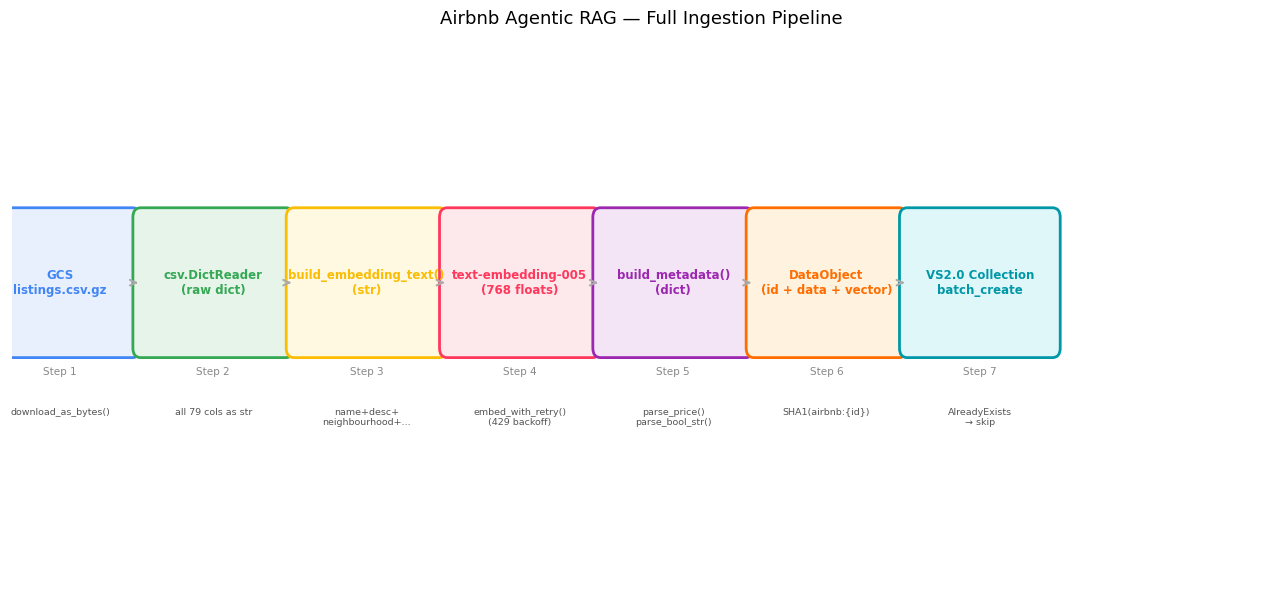

In [56]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")

steps = [
    ("GCS\nlistings.csv.gz",   "#4285F4", "#e8f0fe"),
    ("csv.DictReader\n(raw dict)",        "#34A853", "#e6f4ea"),
    ("build_embedding_text()\n(str)",     "#FBBC04", "#fef9e0"),
    ("text-embedding-005\n(768 floats)",  "#FF385C", "#fde8ec"),
    ("build_metadata()\n(dict)",          "#9C27B0", "#f3e5f5"),
    ("DataObject\n(id + data + vector)",  "#FF6D00", "#fff3e0"),
    ("VS2.0 Collection\nbatch_create",    "#0097A7", "#e0f7fa"),
]

n = len(steps)
xs = [0.5 + i * (9.5 / (n - 1)) for i in range(n)]
y  = 3.0

for i, (label, edge, face) in enumerate(steps):
    box = mpatches.FancyBboxPatch((xs[i]-0.75, y-0.55), 1.5, 1.1,
        boxstyle="round,pad=0.08", linewidth=2, edgecolor=edge, facecolor=face)
    ax.add_patch(box)
    ax.text(xs[i], y, label, ha="center", va="center",
            fontsize=8.5, fontweight="bold", color=edge,
            multialignment="center")
    ax.text(xs[i], y-0.75, f"Step {i+1}", ha="center", va="center",
            fontsize=7.5, color="#888")
    if i < n - 1:
        ax.annotate("", xy=(xs[i+1]-0.75, y), xytext=(xs[i]+0.75, y),
            arrowprops=dict(arrowstyle="->", color="#aaa", lw=1.5))

# Sub-labels below
sublabels = [
    "download_as_bytes()", "all 79 cols as str",
    "name+desc+\nneighbourhood+...", "embed_with_retry()\n(429 backoff)",
    "parse_price()\nparse_bool_str()", "SHA1(airbnb:{id})",
    "AlreadyExists\n→ skip",
]
for i, sub in enumerate(sublabels):
    ax.text(xs[i], y-1.05, sub, ha="center", va="top",
            fontsize=6.8, color="#555", multialignment="center")

ax.set_xlim(0, 13)
ax.set_ylim(0.5, 5)
ax.set_title("Airbnb Agentic RAG — Full Ingestion Pipeline",
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

---
## Dataset Statistics (bonus)

Let's understand the Austin TX Airbnb dataset with some quick charts.

In [57]:
# Parse key fields for 3,000 listings
N = 3000
df = pd.DataFrame([
    {
        "room_type":     r.get("room_type", "Unknown"),
        "neighbourhood": r.get("neighbourhood_cleansed", ""),
        "price":         parse_price(r.get("price", "")) or 0.0,
        "bedrooms":      parse_float(r.get("bedrooms", "")) or 0.0,
        "rating":        parse_float(r.get("review_scores_rating", "")) or 0.0,
        "instant_bookable": parse_bool_str(r.get("instant_bookable", "")),
        "text_len":      len(build_embedding_text(r)),
    }
    for r in all_rows[:N]
])

print(f"DataFrame shape: {df.shape}")
df.describe()

DataFrame shape: (3000, 7)


,price,bedrooms,rating,text_len
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,254.509333,2.089333,4.709827,743.012000
std,485.900341,1.574011,0.874214,233.402844
min,15.000000,0.000000,0.000000,98.000000
25%,88.000000,1.000000,4.810000,598.750000
50%,135.000000,2.000000,4.910000,766.000000
75%,240.000000,3.000000,4.970000,945.000000
max,10041.000000,23.000000,5.000000,1173.000000


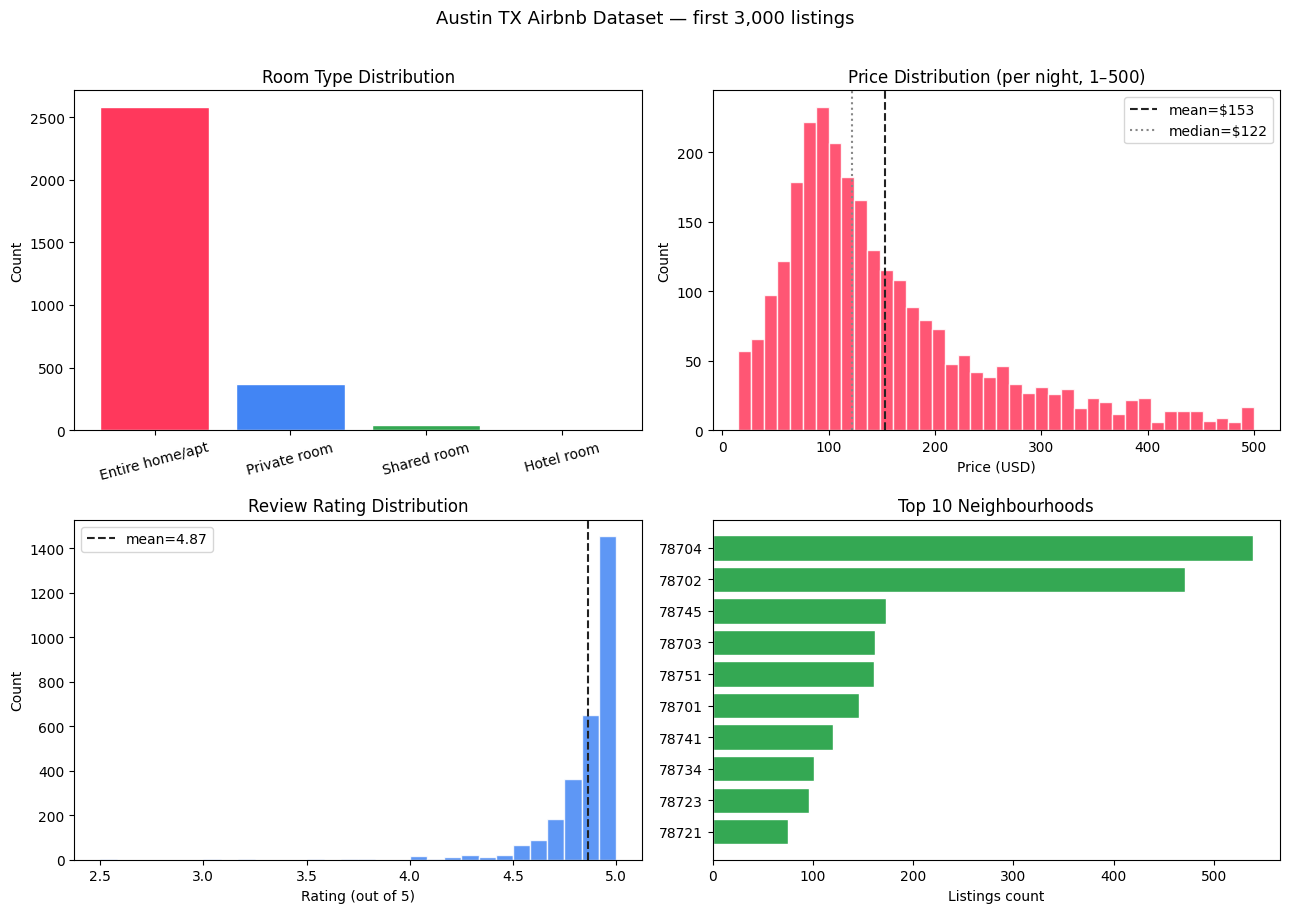

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Room type distribution
rt_counts = df["room_type"].value_counts()
colors = ["#FF385C", "#4285F4", "#34A853", "#FBBC04"]
axes[0,0].bar(rt_counts.index, rt_counts.values, color=colors[:len(rt_counts)], edgecolor="white")
axes[0,0].set_title("Room Type Distribution")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis="x", rotation=15)

# 2. Price distribution (cap at $500 for readability)
prices = df[df["price"].between(1, 500)]["price"]
axes[0,1].hist(prices, bins=40, color="#FF385C", edgecolor="white", alpha=0.85)
axes[0,1].axvline(prices.mean(), color="#222", linestyle="--", label=f"mean=${prices.mean():.0f}")
axes[0,1].axvline(prices.median(), color="#888", linestyle=":", label=f"median=${prices.median():.0f}")
axes[0,1].set_title("Price Distribution (per night, $1–$500)")
axes[0,1].set_xlabel("Price (USD)")
axes[0,1].set_ylabel("Count")
axes[0,1].legend()

# 3. Rating distribution
ratings = df[df["rating"] > 0]["rating"]
axes[1,0].hist(ratings, bins=30, color="#4285F4", edgecolor="white", alpha=0.85)
axes[1,0].axvline(ratings.mean(), color="#222", linestyle="--", label=f"mean={ratings.mean():.2f}")
axes[1,0].set_title("Review Rating Distribution")
axes[1,0].set_xlabel("Rating (out of 5)")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# 4. Top 10 neighbourhoods
top_n = df["neighbourhood"].value_counts().head(10)
axes[1,1].barh(top_n.index[::-1], top_n.values[::-1], color="#34A853", edgecolor="white")
axes[1,1].set_title("Top 10 Neighbourhoods")
axes[1,1].set_xlabel("Listings count")

plt.suptitle(f"Austin TX Airbnb Dataset — first {N:,} listings", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [59]:
# Instant-bookable breakdown
ib = df["instant_bookable"].value_counts()
print("Instant Bookable:")
for k, v in ib.items():
    pct = v / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {k:<8}: {v:4d}  ({pct:.1f}%)  {bar}")

Instant Bookable:
  false   : 2110  (70.3%)  ███████████████████████████████████
  true    :  890  (29.7%)  ██████████████


---
## Summary

You now understand the **complete ingestion pipeline** for the Airbnb Agentic RAG system:

```
GCS (.csv.gz)
   │
   ├─ csv.DictReader → 79 raw string fields per row
   │
   ├─ build_embedding_text()  → ~800 char string (what gets embedded)
   │      name + description[:600] + neighbourhood
   │      + room_type + accommodates + overview[:400]
   │      + bedrooms/beds/bathrooms
   │
   ├─ build_metadata()        → 17-field dict stored in VS2.0
   │      string: name, neighbourhood, room_type, ...
   │      number: price, bedrooms, rating, accommodates, ...
   │      parse_price('$97.00') → 97.0
   │      parse_bool_str('t')   → 'true'
   │
   ├─ make_listing_id()       → SHA1('airbnb:{id}') = deterministic 40-char hex
   │
   ├─ embed_with_retry()      → [768 floats] via text-embedding-005
   │      exponential backoff on 429 ResourceExhausted
   │
   ├─ build_data_object()     → DataObject(id, data, vectors{embedding})
   │
   └─ batch_create_data_objects() → VS2.0 Collection
          AlreadyExists → silently skip (idempotent)
```

**Key design decisions:**
- SHA1 IDs → re-run safely any time
- `top_k × 4` over-fetch in search → metadata filters don't return empty results
- Single `SearchDataObjects` call returns **both** vector + metadata (no Firestore round-trip)
- 0.5s inter-batch sleep + exponential backoff → survives quota limits for 10k+ listings